In [ ]:
import numpy as np #import numpy for mathematical operations
inputs = np.array([2,3])
weights = np.array([0.5,-0.2])
bias=0.1
#(dot product multiples inputs & weights and adds them)
z=np.dot(inputs,weights)+bias
output=max(0,z)   #Apply ReLU activation function(if value < 0 , make it 0)
print("weighted sum:",z)  #print weight sum before activation
print("Neuron output:",output)  #print final neuron output after activation

weighted sum: 0.5
Neuron output: 0.5


###Binary classification problem

In [ ]:
from sklearn.datasets import load_breast_cancer #load real dataset
from sklearn.model_selection import train_test_split  #split data
from sklearn.neural_network import MLPClassifier  #ANN  model
#Load dataset
data=load_breast_cancer()
#split data into train and test
X_train,X_test,y_train,y_test=train_test_split(data.data,data.target,test_size=0.2)
#create ANN model with 2 hidden layer
#multi-layer perceptron
model=MLPClassifier(hidden_layer_sizes=(20,10),max_iter=1000)
 #train model
model.fit(X_train,y_train)
 #print accuracy
print("Final Accuracy:",model.score(X_test,y_test))

Final Accuracy: 0.868421052631579


##This Code Builds a neural network using TensorFlow , train it on cancer data , & predict whether a tumor is malignant or begin.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
# load dataset
data = load_breast_cancer()
# convert to DataFrame
df=pd.DataFrame(data.data,columns=data.feature_names)
#add traget column
df['target']=data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
pd.set_option('display.max_columns',None)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df.shape

(569, 31)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
x=data.data
y=data.target
#split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
#scale
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
#build ANN
model = keras.Sequential([
    keras.layers.Dense(16,activation='relu',input_shape=(x_train.shape[1],)),
    keras.layers.Dense(8,activation='relu'),
    keras.layers.Dense(1,activation='sigmoid')
])
#Sequential = layers added 1 after another
#Dense = fully connected layer
#Relu = activation fun
#16 = number of neuron
#input_shape = number of features

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

####
#optimizer='adam'
#= updates weidhts automatically

#loss='binary_crossentropy'
#= measure error for binary classification

#metrics=['accuracy']
#= shows accuracy during training
#####
#Train

history=model.fit(x_train,y_train,epochs=20,validation_split=0.2)

#Evaluate
model.evaluate(x_test,y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step - accuracy: 0.6346 - loss: 0.6909 - val_accuracy: 0.6044 - val_loss: 0.6521
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6484 - loss: 0.5319 - val_accuracy: 0.6484 - val_loss: 0.5314
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7363 - loss: 0.4343 - val_accuracy: 0.7363 - val_loss: 0.4517
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8297 - loss: 0.3709 - val_accuracy: 0.8022 - val_loss: 0.3934
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8984 - loss: 0.3247 - val_accuracy: 0.8791 - val_loss: 0.3476
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9341 - loss: 0.2891 - val_accuracy: 0.9231 - val_loss: 0.3084
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9423 - loss: 0.2591 - val_accuracy: 0.9341 - val_loss: 0.2752
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9478 - loss: 0.2339 - val_accuracy: 0.9451 - val_los

[0.11426489055156708, 0.9824561476707458]

#Mini Project on ANN Model

###Install & Import requirements

In [ ]:
import numpy as np #numerical operation
import pandas as pd # dataframe handling
import matplotlib.pyplot as plt  #visualization

from sklearn.model_selection import train_test_split #split data
from sklearn.preprocessing import StandardScaler #scaling
import tensorflow as tf #deep learning
from tensorflow import keras

##Load spiral Dataset

In [ ]:
from sklearn.datasets import make_moons
#Generate Data
x,y=make_moons(n_samples=1000,noise=0.2,random_state=42)  #noise= overlaping curve

##Convert to DataFrame

In [ ]:
df=pd.DataFrame(x,columns=['x1','x2'])  # Create dataframe
df['target']=y  #add traget column
print(df.head())

         x1        x2  target
0 -0.111667  0.520224       1
1  1.142650 -0.342577       1
2  0.795558 -0.011442       1
3  0.111827 -0.551932       1
4 -0.816466  0.543996       0


##Visualization

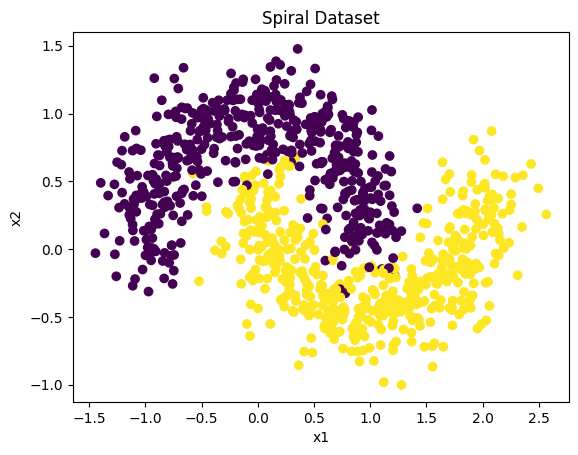

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df['x1'],df['x2'],c=df['target'])
plt.title("Spiral Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

##Train-Test Split

In [ ]:
x=df[['x1','x2']]
y=df['target']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

##Scaling

In [ ]:
scaler = StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

##Build ANN(TensorFlow)

In [ ]:
model=keras.Sequential([
    keras.layers.Dense(64,activation='relu',input_shape=(2,)),
    #First hidden layer with 64 neuron
    #input_shape helps the model to initialize the weights correctly before training data
    keras.layers.Dense(32,activation='relu'),
    #second hidden layer
    keras.layers.Dense(16,activation='relu'),
    #third hidden layer
    keras.layers.Dense(8,activation='relu'),
    #Fourth hidden layer
    keras.layers.Dense(1,activation='sigmoid')
    #output layer for binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##Complie Model

In [ ]:
model.compile(
    optimizer='adam',  #adjusts weights
    loss='binary_crossentropy',  #binary classificaion loss
    metrics=['accuracy']  # track accuracy
)

##Train Model

In [ ]:
history = model.fit(
    x_train,y_train,
    epochs=50,  # number of training cycles
    validation_split=0.2   # validation data
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7234 - loss: 0.6473 - val_accuracy: 0.8938 - val_loss: 0.5692
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8484 - loss: 0.5022 - val_accuracy: 0.9062 - val_loss: 0.3767
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8625 - loss: 0.3534 - val_accuracy: 0.9062 - val_loss: 0.2418
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8734 - loss: 0.2931 - val_accuracy: 0.9125 - val_loss: 0.2057
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8750 - loss: 0.2779 - val_accuracy: 0.9187 - val_loss: 0.1896
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8828 - loss: 0.2641 - val_accuracy: 0.9250 - val_loss: 0.1844
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8875 - loss: 0.2476 - val_accuracy: 0.9312 - val_loss: 0.1673
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8969 - loss: 0.2291 - val_accuracy: 0.9438 - val_loss

##Evaluate Model

In [ ]:
model.evaluate(x_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.9550 - loss: 0.1145


[0.1144808828830719, 0.9549999833106995]

##Predict New Data

In [ ]:
new_data=np.array([[0.5,0.5]])   #x1 & x2
new_data=scaler.transform(new_data)  #scale it
prediction=model.predict(new_data)
print("Prediction Probability:",prediction)
print("Final Class:",(prediction>0.5).astype(int))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
Prediction Probability: [[0.08608233]]
Final Class: [[0]]


##Decision Boundary Visulization

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


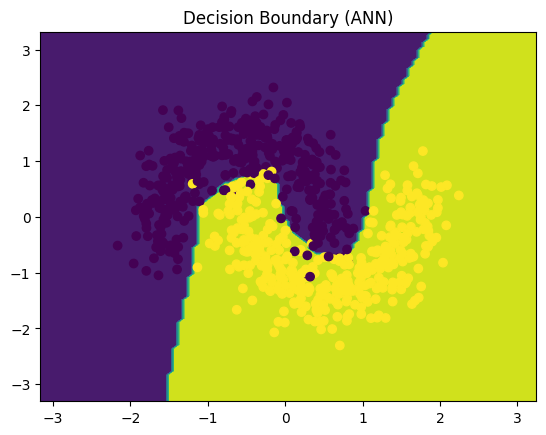

In [ ]:
#Create mesh grid
x_min, x_max = x_train[:,0].min()-1,x_train[:,0].max()+1  #x-axis range
y_min, y_max = x_train[:,1].min()-1,x_train[:,1].max()+1  #y-axis range

#create grid points                                #   Grid
xx , yy = np.meshgrid(
    np.linspace(x_min,x_max,100),  # x grid values
    np.linspace(y_min,y_max,100)   # y grid values
)

#combine grid into points
grid=np.c_[xx.ravel(),yy.ravel()]  # flatten grid
# ravel()= converts matrix into a long vector
# np.c_[]= combines x & y into pairs

#Predict  for grid
z=model.predict(grid)  # model predictions

#convert probabailites to class             # Decision
z=(z>0.5).astype(int)  # binary output

#Reshape to grid shape
z=z.reshape(xx.shape)  #match grid

#plot decision boundary
plt.contourf(xx,yy,z)  # filled contour

#plot training points                     # Points
plt.scatter(x_train[:,0],x_train[:,1],c=y_train)  # actual  points

#Add title
plt.title("Decision Boundary (ANN)")   # plot title
#show plot
plt.show()  #display plot

### Combined Code for Train-Test Split, Scaling, and Decision Boundary Visualization

This cell combines the previous steps for train-test split, data scaling, and decision boundary plotting to ensure all variables are defined and processed in the correct order.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


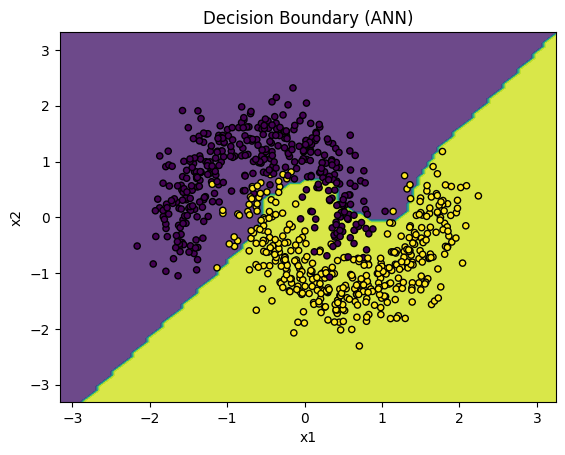

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
import pandas as pd
import tensorflow as tf # Import tensorflow
from tensorflow import keras # Import keras

# 0. Generate Data and Create DataFrame (from cells xkuZFYn0OSoK and ROLuHCXGP1pE)
x_raw, y_raw = make_moons(n_samples=1000, noise=0.2, random_state=42)
df = pd.DataFrame(x_raw, columns=['x1','x2'])
df['target'] = y_raw

# 1. Train-Test Split (from cell IqUzDmA5nHCQ)
x = df[['x1','x2']]
y = df['target']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 2. Scaling (from cell APPnHKREoj63)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# 3. Build ANN (from cell RgGrvePTLJFt)
model=keras.Sequential([
    keras.layers.Dense(64,activation='relu',input_shape=(2,)),
    keras.layers.Dense(32,activation='relu'),
    keras.layers.Dense(16,activation='relu'),
    keras.layers.Dense(8,activation='relu'),
    keras.layers.Dense(1,activation='sigmoid')
])

# 4. Compile Model (from cell gS9pLTnRNS00)
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5. Train Model (This step is needed for the model to learn)
history = model.fit(
    x_train,y_train,
    epochs=50,
    validation_split=0.2,
    verbose=0 # Suppress verbose output for cleaner plot generation
)

# 6. Decision Boundary Visualization (adapted from cell Cb0kcEJdSr2L)
# Create mesh grid
x_min, x_max = x_train[:,0].min()-1, x_train[:,0].max()+1  # x-axis range
y_min, y_max = x_train[:,1].min()-1, x_train[:,1].max()+1  # y-axis range

# Create grid points
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),  # x grid values
    np.linspace(y_min, y_max, 100)    # y grid values
)

# Combine grid into points
grid = np.c_[xx.ravel(), yy.ravel()]  # flatten grid

# Predict for grid
# Scale the grid points using the same scaler fitted on x_train
grid_scaled = scaler.transform(grid)
z = model.predict(grid_scaled, verbose=0)  # model predictions, suppress verbose

# Convert probabilities to class
z = (z > 0.5).astype(int)

# Reshape to grid shape
z = z.reshape(xx.shape)  # match grid

# Plot decision boundary
plt.contourf(xx, yy, z, alpha=0.8, cmap='viridis')  # filled contour

# Plot training points
plt.scatter(x_train[:,0], x_train[:,1], c=y_train, cmap='viridis', edgecolors='k', s=20)  # actual points

# Add title
plt.title("Decision Boundary (ANN)")   # plot title
plt.xlabel("x1")
plt.ylabel("x2")

# Show plot
plt.show()

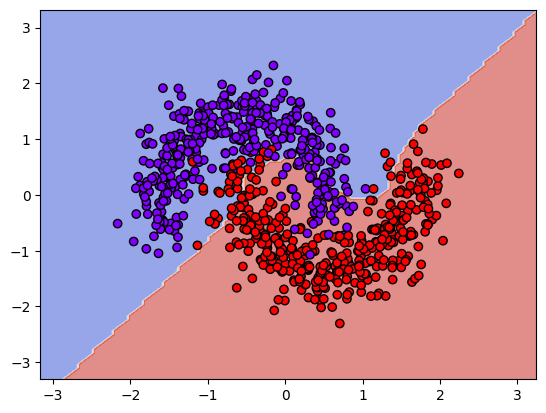

In [ ]:
plt.contourf(xx,yy,z,cmap='coolwarm', alpha=0.6)  # change the background color
plt.scatter(
    x_train[:,0],
    x_train[:,1],
    c=y_train,
    cmap='rainbow',  # same color theme
    edgecolors='k'
)
plt.show()

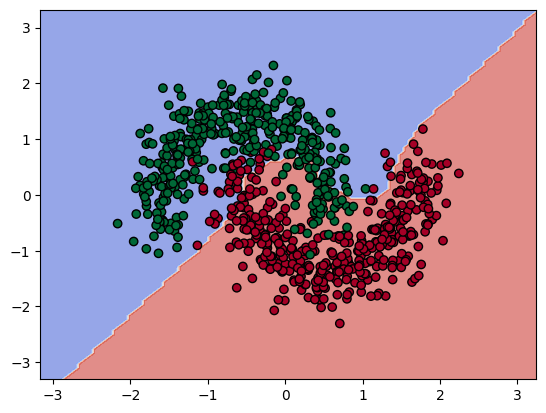

In [ ]:
plt.contourf(xx,yy,z,cmap='coolwarm', alpha=0.6)  # change the background color
plt.scatter(
    x_train[:,0],
    x_train[:,1],
    c=y_train,
    cmap='RdYlGn_r',  # same color theme
    edgecolors='k'
)
plt.show()